In [1]:
import numpy as np
import matplotlib.pyplot as plt
from generators import MultipleSpeedCrossingBar
from networks import LateralInhibitoryLayer

# 1. Setup Generator (I.I.D. samples)
screen_size = 12
gen_params = MultipleSpeedCrossingBar.default_params()
gen_params['screen_size'] = screen_size
gen_params['bar_size'] = 1
gen_params['speed'] = 1
gen_params['noise'] = 0.05

gen = MultipleSpeedCrossingBar(gen_params)

# 2. Setup Network
hparams = LateralInhibitoryLayer.default_hparams((screen_size, screen_size, 1))
hparams['num_units_y'] = 100  # Creating 100 units to plot a 10x10 grid of Receptive Fields
hparams['w_lr'] = 0.005       # Feedforward learning rate
hparams['m_lr'] = 0.01       # Lateral inhibitory learning rate
hparams['p_lr'] = 0.005       # Temporal prediction learning rate
hparams['w_update'] = 'bcm_abs' # Using a BCM-like update rule for feedforward weights
hparams['m_update'] = 'hebbian'   # Using a classic update rule for lateral inhibition
hparams['p_update'] = 'bcm_abs'   # Using a BCM-like update rule for temporal prediction

net = LateralInhibitoryLayer(hparams)
net.reset_network()


In [2]:

# Training parameters
num_iterations = 1000  # Number of sequences to train on
sequence_length = 10   # Number of epochs/frames per sequence
active_matrices = ['w', 'm', 'p'] # Matrices to update during training

# Training loop
for i in range(num_iterations):
    # Set generator to a random initial position for the new sequence
    gen.set_random_position()
    
    # Reset network activations at the beginning of the sequence
    net.reset_activations()
    
    for t in range(sequence_length):
        # Update generator position for subsequent steps in the sequence
        if t > 0:
            gen.set_next_position()
            
        current_input = gen.get_current_frame()
        
        # Prepare network for a new epoch/step
        net.new_epoch()
        
        # Feed the frame to the network and update
        net.update_activations(current_input, train=True)
        net.update_counts()
        net.update_parameters(active_matrices)

    if (i + 1) % 100 == 0:
        print(f"Completed {i + 1} iterations")
        
print("Training completed.")

Completed 100 iterations
Completed 200 iterations
Completed 300 iterations
Completed 400 iterations
Completed 500 iterations
Completed 600 iterations
Completed 700 iterations
Completed 800 iterations
Completed 900 iterations
Completed 1000 iterations
Training completed.


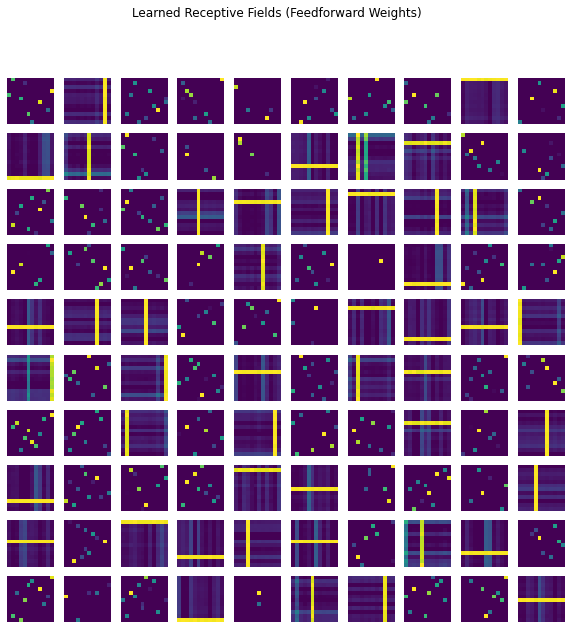

In [3]:
# 5. Plotting Learned Receptive Fields
W = net.w
num_units = W.shape[0]
grid_size = int(np.sqrt(num_units))

plt.figure(figsize=(10, 10))
for i in range(num_units):
    plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(W[i].reshape(screen_size, screen_size))
    plt.axis('off')
plt.suptitle("Learned Receptive Fields (Feedforward Weights)")
plt.show()

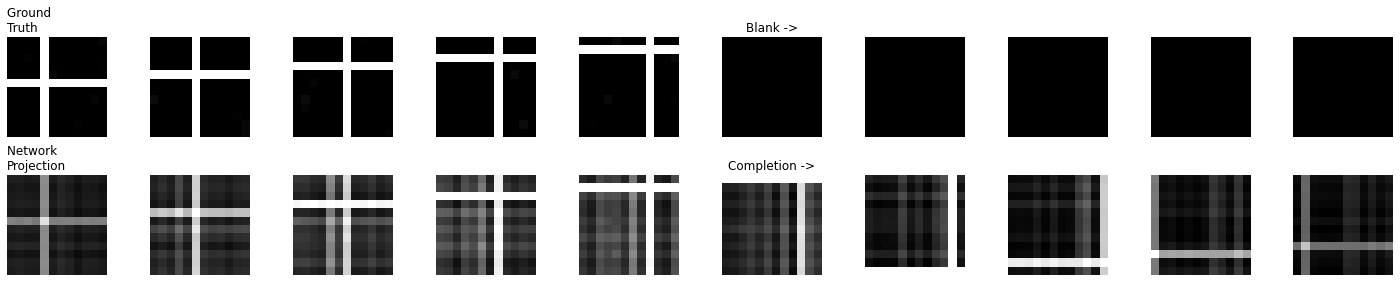

In [7]:

# Parameters for sequence completion
half_seq_length = sequence_length // 2

# Generate a new random sequence
gen.set_random_position()
net.reset_activations()

ground_truth_frames = []
reconstructed_frames = []

# Process the sequence
for t in range(sequence_length):
    if t > 0:
        gen.set_next_position()
        
    current_input = gen.get_current_frame()
    ground_truth_frames.append(current_input)
    
    # Prepare network for a new epoch/step
    net.new_epoch()
    
    if t < half_seq_length:
        # First half: Provide the actual frame to the network
        net.update_activations(current_input, train=False)
    else:
        # Second half: Provide a blank frame, forcing network to use temporal prediction
        net.update_activations_blank()
        
    # Reconstruct the expected input from the network's internal projection
    reconstructed_frames.append(net.projection())

# Visualization
fig, axes = plt.subplots(2, sequence_length, figsize=(2 * sequence_length, 4))

for t in range(sequence_length):
    # Plot Ground Truth
    if t < half_seq_length:
        axes[0, t].imshow(ground_truth_frames[t].squeeze(), cmap='gray', vmin=0, vmax=1)
    else:
        axes[0, t].imshow(np.zeros_like(ground_truth_frames[t]).squeeze(), cmap='gray', vmin=0, vmax=1)  # Blank frame
    axes[0, t].axis('off')
    if t == 0:
        axes[0, t].set_title('Ground \nTruth', loc='left')
    if t == half_seq_length:
        axes[0, t].set_title('Blank ->')
        
    # Plot Network Reconstruction
    axes[1, t].imshow(reconstructed_frames[t].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, t].axis('off')
    if t == 0:
        axes[1, t].set_title('Network \nProjection', loc='left')
    if t == half_seq_length:
        axes[1, t].set_title('Completion ->')

plt.tight_layout()
plt.show()